# Trabalho 02 - Aprendizado de máquina
Aluno: Pedro Tashima

## Instala e importa pacotes

In [37]:
!python3 -m pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [38]:
import pandas as pd

## Lê dados

In [39]:
df=pd.read_csv('../data/gdp-and-homicides-vs-happiness-vs-hdi_FabroClassification2025OK_4classes.csv', sep=";")

df.head()

,Country Name,Country Code,World regions according to OWID,Intentional homicides (per 100000 people) as of 2021,Intentional homicides/100k x 100,Cantril ladder score,Cantril ladder score*1000,GDP per capita. PPP (constant 2021 international $),HDI (Human Development Indicator) Value (0~1000),Country Class,Class 4,Class 3,Class 2,Class 1
0,Afghanistan,AFG,Asia,4.02,402,1.721,1721,1992,462,4,1,0,0,0
1,Albania,ALB,Europe,2.31,231,5.304,5304,18244,789,2,0,0,1,0
2,Argentina,ARG,South America,4.62,462,6.188,6188,27105,849,2,0,0,1,0
3,Armenia,ARM,Asia,2.19,219,5.455,5455,19230,786,2,0,0,1,0
4,Australia,AUS,Oceania,0.74,74,7.057,7057,59553,946,1,0,0,0,1


## Análise exploratória

In [40]:
print("valores nulos: ")
print(df.isna().sum())
print("--------------------------------------")
print("informacoes gerais: ")
print(df.info())
print("--------------------------------------")

valores nulos: 
Country Name                                            0
Country Code                                            0
World regions according to OWID                         0
Intentional homicides (per 100000 people) as of 2021    0
Intentional homicides/100k  x 100                       0
Cantril ladder score                                    0
Cantril ladder score*1000                               0
GDP per capita. PPP (constant 2021 international $)     0
HDI (Human Development Indicator) Value (0~1000)        0
Country Class                                           0
Class 4                                                 0
Class 3                                                 0
Class 2                                                 0
Class 1                                                 0
dtype: int64
--------------------------------------
informacoes gerais: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 14 colu

In [41]:
df.describe()

,Intentional homicides (per 100000 people) as of 2021,Intentional homicides/100k x 100,Cantril ladder score,Cantril ladder score*1000,GDP per capita. PPP (constant 2021 international $),HDI (Human Development Indicator) Value (0~1000),Country Class,Class 4,Class 3,Class 2,Class 1
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.00000
mean,5.372545,537.254545,5.766727,5766.727273,32930.645455,783.272727,1.963636,0.081818,0.200000,0.318182,0.40000
std,8.963389,896.338888,1.125598,1125.597529,27136.586828,138.046855,0.966667,0.275342,0.401831,0.467902,0.49214
min,0.070000,7.000000,1.721000,1721.000000,1992.000000,438.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,0.802500,80.250000,5.020750,5020.750000,10112.500000,702.250000,1.000000,0.000000,0.000000,0.000000,0.00000
50%,1.950000,195.000000,5.974000,5974.000000,26161.500000,800.500000,2.000000,0.000000,0.000000,0.000000,0.00000
75%,4.620000,462.000000,6.576250,6576.250000,49467.500000,906.750000,3.000000,0.000000,0.000000,1.000000,1.00000
max,52.130000,5213.000000,7.741000,7741.000000,132847.000000,967.000000,4.000000,1.000000,1.000000,1.000000,1.00000


### Divide o dataframe em treino e teste

In [42]:
from sklearn.model_selection import train_test_split

feature_names = ["Cantril ladder score", "GDP per capita. PPP (constant 2021 international $)", "HDI (Human Development Indicator) Value (0~1000)"]

X = df[feature_names]
y = df["Country Class"]

df_train, df_test = train_test_split(df, test_size=0.7, random_state=10)

X_train = df_train[feature_names]
y_train = df_train["Country Class"]

X_test = df_test[feature_names]
y_test = df_test["Country Class"]

### Decision tree

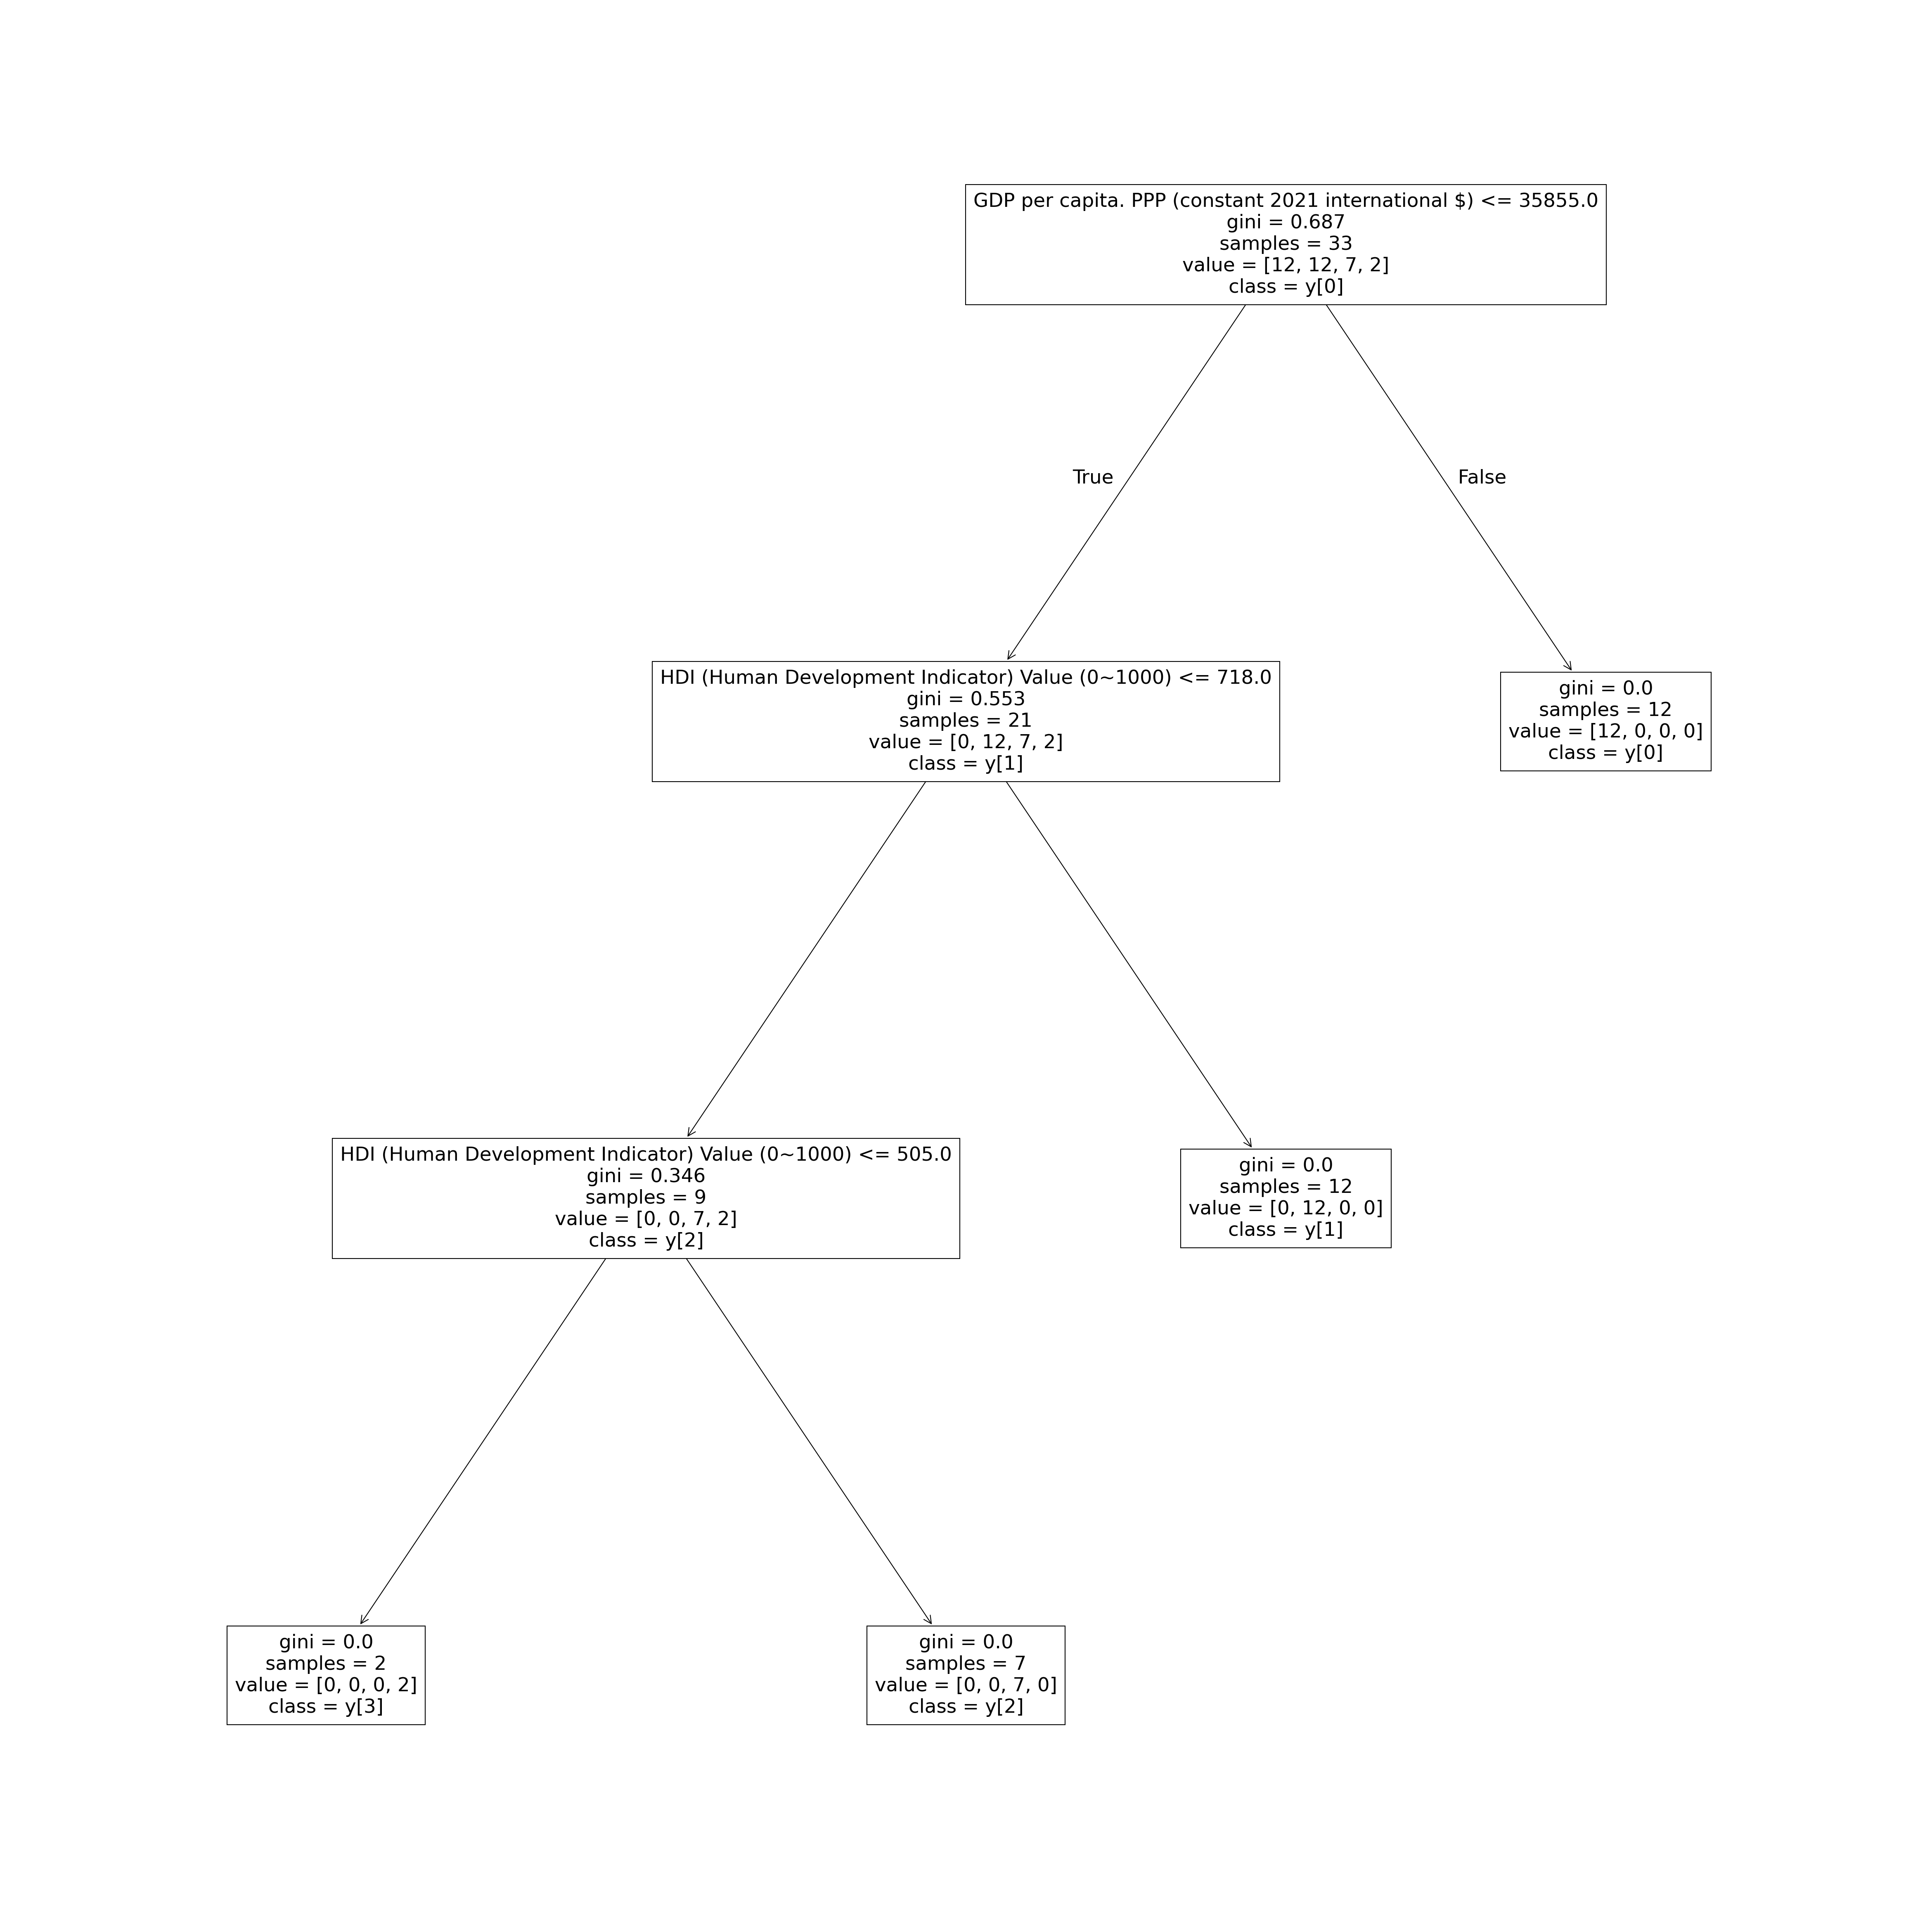

In [43]:
from sklearn import tree
from matplotlib import pyplot as plt

clf = tree.DecisionTreeClassifier()

clf.fit(X_train, y_train)

fig = plt.figure(figsize=(40,40), dpi=150)
tree.plot_tree(clf, feature_names=feature_names, class_names=True)
plt.show()

In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

scores = cross_val_score(clf, X_train, y_train, cv=10)

print(scores.mean())

y_pred = clf.predict(X_test)
print("Erro quadrático Médio: %.2f" % mean_squared_error(y_test, y_pred))
print("R2: %.4f" % r2_score(y_test, y_pred))

0.975
Erro quadrático Médio: 0.12
R2: 0.8798


/Users/pedro/code/tashima42/disciplinas/ciencia-de-dados/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


### Random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

scores = cross_val_score(rf, X_train, y_train, cv=10)

print(scores.mean())

y_pred_rf = rf.predict(X_test)

print("Erro quadrático Médio: %.2f" % mean_squared_error(y_test, y_pred_rf))
print("R2: %.4f" % r2_score(y_test, y_pred_rf))

/Users/pedro/code/tashima42/disciplinas/ciencia-de-dados/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


0.925
Erro quadrático Médio: 0.10
R2: 0.8932
